### Importing packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
np.random.seed(0)

### Plotting functions

In [2]:
# Some functions to plot our points and draw the models
def plot_points(features, labels, size_of_points=100):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    plt.scatter([s[0][0] for s in spam],
                [s[0][1] for s in spam],
                s = size_of_points,
                color = 'cyan',
                edgecolor = 'k',
                marker = '^')
    plt.scatter([s[0][0] for s in ham],
                [s[0][1] for s in ham],
                s = size_of_points,
                color = 'red',
                edgecolor = 'k',
                marker = 's')
    #pyplot.xlabel('GRE')
    #pyplot.ylabel('TOEFL')
    #pyplot.legend(['Admitted','Not admitted'])

def plot_model(X, y, model, size_of_points=100):
    X = np.array(X)
    y = np.array(y)
    plot_step = 0.2
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 1)
    plot_points(X, y, size_of_points)
    plt.show()
    
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

def display_tree(dt):
    plt.figure(figsize=(10, 6))

    plot_tree(
        dt,
        filled=True,
        rounded=True
    )

    plt.show()

### Loading the dataset
For the next two cells, please run only one of them.
- Run the first cell if you cloned the Github Repo
- Run the second cell if you opened this as a Google Colab

In [3]:
# IMPORTANT: ONLY RUN THIS CELL IF YOU HAVE CLONED THE REPO
data = pd.read_csv('Admission_Predict.csv', index_col=0)
data

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
396,324,110,3,3.5,3.5,9.04,1,0.82
397,325,107,3,3.0,3.5,9.11,1,0.84
398,330,116,4,5.0,4.5,9.45,1,0.91


In [ ]:
# IMPORTANT: ONLY RUN THIS CELL IF YOU ARE WORKING ON A COLAB 

url = "https://raw.githubusercontent.com/luisguiserrano/manning/master/Chapter_09_Decision_Trees/Admission_Predict.csv"
data = pd.read_csv(url)
data.head()

In [4]:
data['Admitted'] = data['Chance of Admit'] >= 0.75

In [5]:
data = data.drop(['Chance of Admit'], axis=1)

In [6]:
data

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Admitted
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,True
2,324,107,4,4.0,4.5,8.87,1,True
3,316,104,3,3.0,3.5,8.00,1,False
4,322,110,3,3.5,2.5,8.67,1,True
5,314,103,2,2.0,3.0,8.21,0,False
...,...,...,...,...,...,...,...,...
396,324,110,3,3.5,3.5,9.04,1,True
397,325,107,3,3.0,3.5,9.11,1,True
398,330,116,4,5.0,4.5,9.45,1,True


In [7]:
features = data.drop(['Admitted'], axis=1)
labels = data['Admitted']

In [8]:
features

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
Serial No.,,,,,,,
1,337,118,4,4.5,4.5,9.65,1
2,324,107,4,4.0,4.5,8.87,1
3,316,104,3,3.0,3.5,8.00,1
4,322,110,3,3.5,2.5,8.67,1
5,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
396,324,110,3,3.5,3.5,9.04,1
397,325,107,3,3.0,3.5,9.11,1
398,330,116,4,5.0,4.5,9.45,1


In [9]:
labels

Serial No.
1       True
2       True
3      False
4       True
5      False
       ...  
396     True
397     True
398     True
399    False
400     True
Name: Admitted, Length: 400, dtype: bool

# Training a decision tree

In [10]:
dt = DecisionTreeClassifier()

In [11]:
dt.fit(features, labels)

DecisionTreeClassifier()

In [12]:
dt.predict(features[0:5])

array([ True,  True, False,  True, False])

In [13]:
dt.score(features, labels)

1.0

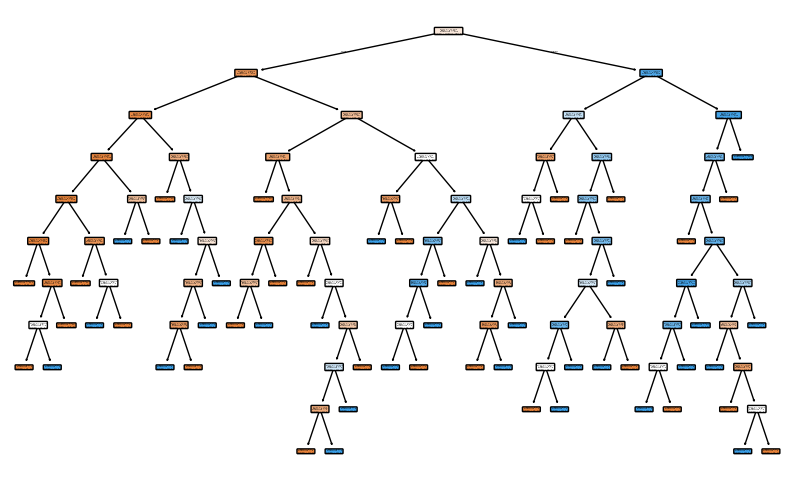

In [14]:
display_tree(dt) #this is overfit

# Training a smaller tree that doesn't overfit

In [15]:
dt_smaller = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=10)

In [16]:
dt_smaller.fit(features, labels)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=10)

In [17]:
dt_smaller.score(features, labels)

0.885

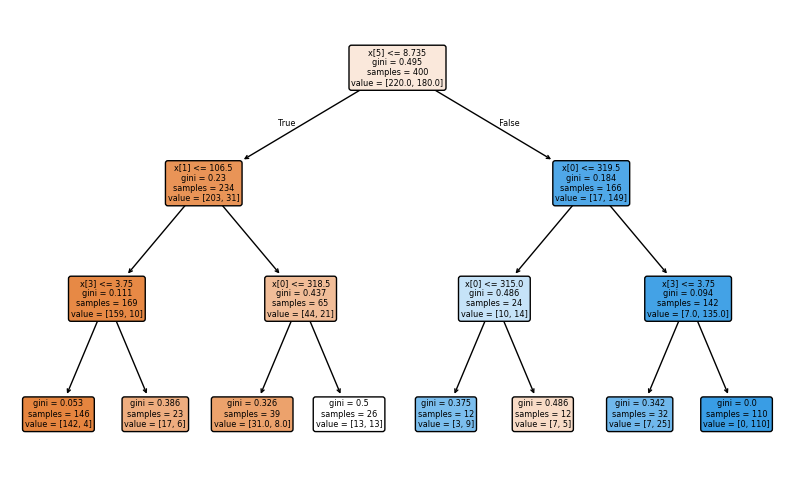

In [18]:
display_tree(dt_smaller) #cant plot_points and plot_model for the 7 features because they can only draw 2 features at a time due to xy axis

### Using the tree to make predictions

In [20]:
dt_smaller.predict([[320,
                     110,
                     3,
                     4.0,
                     3.5,
                     8.9,
                     0]])

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [21]:
# A node in the white (neutral) leaf gets a false prediction
dt_smaller.predict([[320,
                     110,
                     3,
                     4.0,
                     3.5,
                     8.0,
                     0]])

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([False])

# Training a decision tree with only two features

In [22]:
#exams = data[['GRE Score', 'CGPA']]
exams = data[['GRE Score', 'TOEFL Score']]
exams

,GRE Score,TOEFL Score
Serial No.,,
1,337,118
2,324,107
3,316,104
4,322,110
5,314,103
...,...,...
396,324,110
397,325,107
398,330,116


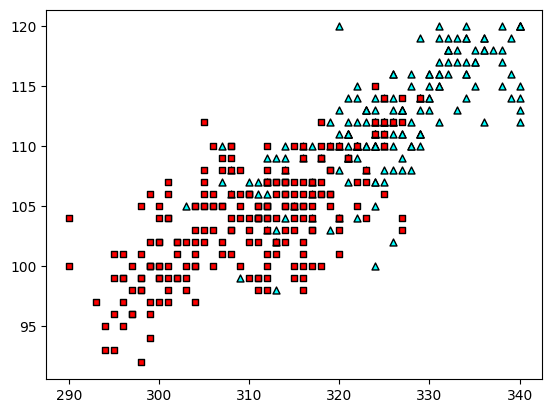

In [23]:
plot_points(exams, labels, size_of_points=25) #can only do 2 features for the plot

### Fitting a tree of depth 2

In [27]:
dt_exams = DecisionTreeClassifier(max_depth=2, min_samples_leaf=10, min_samples_split=10)
#dt_exams = DecisionTreeClassifier(max_depth=2)

In [28]:
dt_exams.fit(exams, labels)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=10, min_samples_split=10)

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


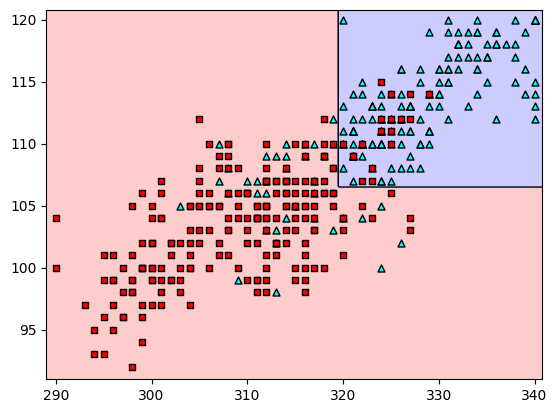

In [29]:
plot_model(exams, labels, dt_exams, size_of_points=25)

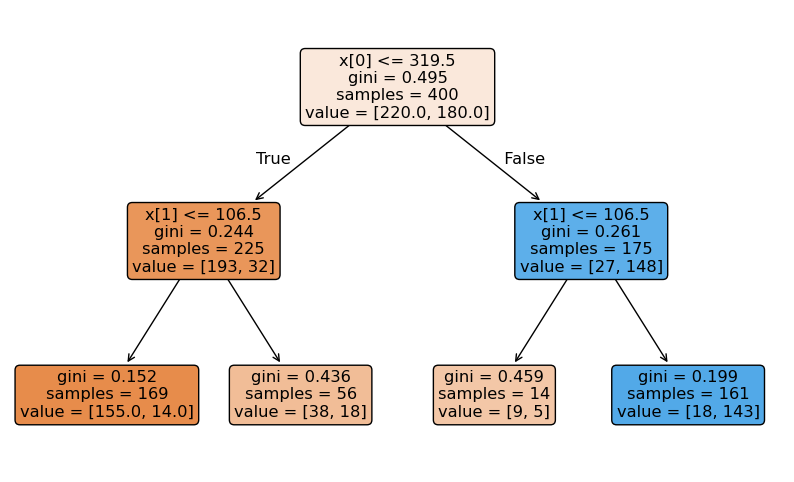

In [30]:
display_tree(dt_exams)

### Fitting a tree of depth 1

In [31]:
simpler_dt_exams = DecisionTreeClassifier(max_depth=1)
simpler_dt_exams.fit(exams, labels)

DecisionTreeClassifier(max_depth=1)

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


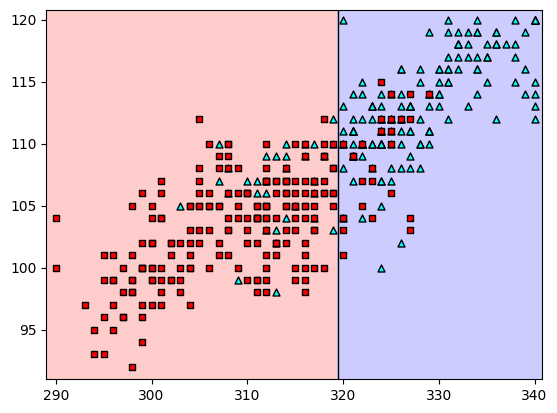

In [32]:
plot_model(exams, labels, simpler_dt_exams, size_of_points=25)

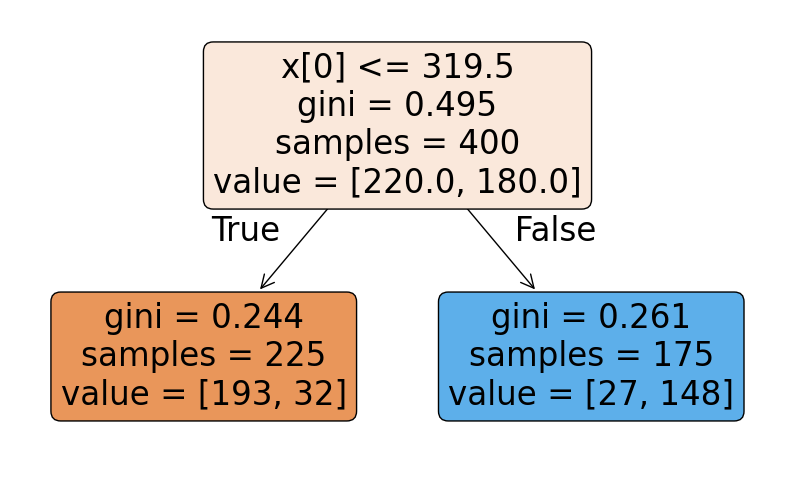

In [33]:
display_tree(simpler_dt_exams)

### Fitting a tree of unbounded depth (overfitting)

In [34]:
crazy_dt_exams = DecisionTreeClassifier()
crazy_dt_exams.fit(exams, labels)

DecisionTreeClassifier()

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


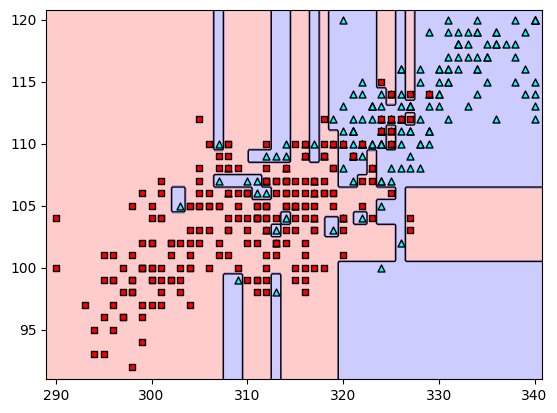

In [35]:
plot_model(exams, labels, crazy_dt_exams, size_of_points=25)

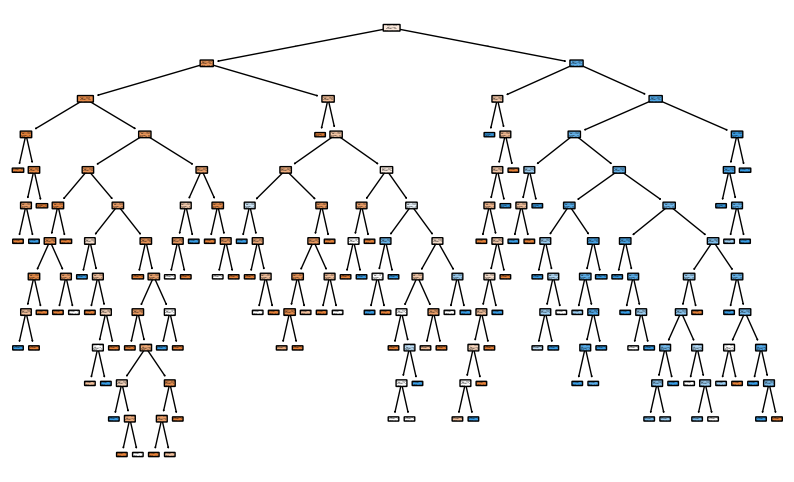

In [36]:
display_tree(crazy_dt_exams)